In [54]:
!pip install youtube-comment-downloader transformers matplotlib pandas wordcloud scikit-learn seaborn -q

In [55]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, accuracy_score
)
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from transformers import pipeline as hf_pipeline
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [56]:
from youtube_comment_downloader import YoutubeCommentDownloader

video_url = "https://www.youtube.com/watch?v=FEgCIRHoVa0"
downloader = YoutubeCommentDownloader()

comments_raw = []
for c in downloader.get_comments_from_url(video_url):
    comments_raw.append({
        'text': c['text'],
        'likes': c.get('votes', 0),
        'time': c.get('time', '')
    })
    if len(comments_raw) >= 350:
        break

df_raw = pd.DataFrame(comments_raw)
print(f'Total komentar terkumpul: {len(df_raw)}')
print(df_raw.head())

Total komentar terkumpul: 346
                                                text likes            time
0   Tapi skr pak pur pun sepertinya sdh masyuk angin     0  11 minutes ago
1          IMF cuma mau mengendalikan BUMN indonesia     0  25 minutes ago
2                        Sehat selalu Bapak Purbaya🤲     0  29 minutes ago
3                                     Pinter ngarang     0  31 minutes ago
4  Sblm Pak Pur, sang (mantan) menkeu srg dipuja-...     0      1 hour ago


In [57]:
slang_dict = {
    'gak': 'tidak', 'ga': 'tidak', 'nggak': 'tidak', 'ngga': 'tidak',
    'gk': 'tidak', 'tdk': 'tidak', 'tdk': 'tidak', 'g': 'tidak',
    'udah': 'sudah', 'udh': 'sudah', 'dah': 'sudah',
    'emg': 'memang', 'emang': 'memang',
    'bgt': 'banget', 'bngt': 'banget',
    'krn': 'karena', 'karna': 'karena',
    'utk': 'untuk', 'tuk': 'untuk',
    'yg': 'yang', 'yng': 'yang',
    'dgn': 'dengan', 'dg': 'dengan',
    'dr': 'dari', 'dri': 'dari',
    'klo': 'kalau', 'kalo': 'kalau', 'klu': 'kalau',
    'jg': 'juga', 'jga': 'juga',
    'sdh': 'sudah', 'suda': 'sudah',
    'sy': 'saya', 'gw': 'saya', 'gue': 'saya', 'aku': 'saya',
    'lo': 'kamu', 'lu': 'kamu', 'elo': 'kamu',
    'tp': 'tapi', 'tpi': 'tapi',
    'sm': 'sama', 'ama': 'sama',
    'pd': 'pada', 'kpd': 'kepada',
    'spy': 'supaya', 'biar': 'supaya',
    'msh': 'masih', 'masi': 'masih',
    'hrs': 'harus', 'hrus': 'harus',
    'blm': 'belum', 'belom': 'belum',
    'sdg': 'sedang', 'lg': 'sedang', 'lagi': 'sedang',
    'bs': 'bisa', 'bsa': 'bisa',
    'mk': 'maka', 'mkn': 'makan',
    'nih': 'ini', 'tuh': 'itu', 'ni': 'ini',
    'ntar': 'nanti', 'tar': 'nanti',
    'ok': 'oke', 'oks': 'oke',
    'wkwk': '', 'wkwkwk': '', 'haha': '', 'hehe': '',
    'anjir': '', 'anjing': '', 'bangsat': '',
    'pemerintah': 'pemerintah', 'rakyat': 'rakyat',
}


stopwords_id = set([
    'yang', 'dan', 'di', 'ini', 'itu', 'dengan', 'ke', 'dari',
    'pada', 'untuk', 'adalah', 'dalam', 'tidak', 'ada', 'juga',
    'akan', 'atau', 'sudah', 'saya', 'kita', 'mereka', 'kami',
    'bisa', 'tapi', 'jika', 'karena', 'kalau', 'maka', 'oleh',
    'saat', 'bagi', 'bahwa', 'serta', 'agar', 'namun', 'tetapi',
    'meski', 'seperti', 'sangat', 'lebih', 'sudah', 'masih',
    'belum', 'harus', 'sama', 'semua', 'saja', 'jadi', 'lagi',
    'nya', 'lah', 'pun', 'kah', 'ya', 'yah', 'dong', 'deh',
    'sih', 'nih', 'tuh', 'gitu', 'gini', 'kan', 'nah',
])

def normalize_slang(text):
    words = text.split()
    normalized = [slang_dict.get(w, w) for w in words]
    return ' '.join([w for w in normalized if w])

def remove_stopwords(text):
    words = text.split()
    return ' '.join([w for w in words if w not in stopwords_id])

def clean_text(text):
    text = str(text)
    text = re.sub(r'<.*?>', '', text)          #HTML tags
    text = re.sub(r'http\S+', '', text)         #URLs
    text = re.sub(r'@\w+', '', text)            #mentions
    text = re.sub(r'#\w+', '', text)            #hashtags
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text) #special chars
    text = re.sub(r'\s+', ' ', text).strip()    #extra spaces
    text = text.lower()                          #lowercase
    text = normalize_slang(text)                 #slang normalization
    text = remove_stopwords(text)               #stopword removal
    return text

df = df_raw.copy()
df['text_original'] = df['text']
df['text_clean'] = df['text'].apply(clean_text)

df = df[df['text_clean'].str.len() > 5].reset_index(drop=True)

print(f'Data setelah preprocessing: {len(df)} komentar')
print('\nContoh hasil preprocessing:')
for i in range(3):
    print(f'  Original : {df["text_original"][i][:80]}')
    print(f'  Cleaned  : {df["text_clean"][i][:80]}')
    print()

Data setelah preprocessing: 335 komentar

Contoh hasil preprocessing:
  Original : Tapi skr pak pur pun sepertinya sdh masyuk angin
  Cleaned  : skr pak pur sepertinya masyuk angin

  Original : IMF cuma mau mengendalikan BUMN indonesia
  Cleaned  : imf cuma mau mengendalikan bumn indonesia

  Original : Sehat selalu Bapak Purbaya🤲
  Cleaned  : sehat selalu bapak purbaya



In [58]:
from transformers import pipeline as hf_pipeline

classifier = hf_pipeline(
    'sentiment-analysis',
    model='nlptown/bert-base-multilingual-uncased-sentiment',
    truncation=True,
    max_length=512
)

def map_sentiment(label):
    stars = int(label[0])
    if stars <= 2:
        return 'NEGATIVE'
    elif stars == 3:
        return 'NEUTRAL'
    else:
        return 'POSITIVE'

def get_sentiment_full(text):
    try:
        result = classifier(text[:512])[0]
        label = map_sentiment(result['label'])
        score = round(result['score'], 4)
        return label, score
    except:
        return 'NEUTRAL', 0.0

print('Menjalankan BERT classifier...')
results = df['text_clean'].apply(get_sentiment_full)
df['sentiment'] = results.apply(lambda x: x[0])
df['confidence'] = results.apply(lambda x: x[1])

print('Selesai!')
print('\nDistribusi sentimen:')
print(df['sentiment'].value_counts())
print(f'\nRata-rata confidence: {df["confidence"].mean():.4f}')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Menjalankan BERT classifier...
Selesai!

Distribusi sentimen:
sentiment
NEGATIVE    187
POSITIVE    104
NEUTRAL      44
Name: count, dtype: int64

Rata-rata confidence: 0.4178


In [59]:
import random
random.seed(42)

sample_idx = random.sample(range(len(df)), min(50, len(df)))
df_sample = df.iloc[sample_idx].reset_index(drop=True)

print('=== 50 KOMENTAR UNTUK MANUAL LABELING ===')
print('Baca setiap komentar dan tentukan labelnya: POSITIVE / NEGATIVE / NEUTRAL')
print('Isi di cell berikutnya pada variabel manual_labels')
print()
for i, row in df_sample.iterrows():
    print(f'[{i:2d}] Original : {row["text_original"][:90]}')
    print(f'     BERT pred: {row["sentiment"]} (conf: {row["confidence"]:.2f})')
    print()

=== 50 KOMENTAR UNTUK MANUAL LABELING ===
Baca setiap komentar dan tentukan labelnya: POSITIVE / NEGATIVE / NEUTRAL
Isi di cell berikutnya pada variabel manual_labels

[ 0] Original : Wedus penghianat
     BERT pred: NEGATIVE (conf: 0.51)

[ 1] Original : Siapa yang kerja? Ini orang,yg lain mengganggu
     BERT pred: POSITIVE (conf: 0.26)

[ 2] Original : Yg satu kerja keras buat perbaiki ekonomi negara, yg satu buang2 uang negara. 😂😂
     BERT pred: POSITIVE (conf: 0.42)

[ 3] Original : Nambah hutang nambah masalah
     BERT pred: NEGATIVE (conf: 0.41)

[ 4] Original : imf mah parasit 😂😂, jgn mau jadi budak george soros 😂
     BERT pred: NEGATIVE (conf: 0.71)

[ 5] Original : Sia2 menkeu hebat seperti purbaya ini. Uangnya dihambur hamburkan ke mbg. 😂😂😂
     BERT pred: NEGATIVE (conf: 0.71)

[ 6] Original : Hati2 pak purbaya mereka punya kepentingan,mereka orang2 licik,
     BERT pred: POSITIVE (conf: 0.37)

[ 7] Original : Pemerintah butuh uang jangan pinjam ke negara lain tapi utang

In [60]:
manual_labels = {
    0:  'NEGATIVE',
    1:  'NEGATIVE',
    2:  'POSITIVE',
    3:  'NEGATIVE',
    4:  'NEGATIVE',
    5:  'POSITIVE',
    6:  'NEGATIVE',
    7:  'NEGATIVE',
    8:  'NEGATIVE',
    9:  'NEGATIVE',
    10: 'NEGATIVE',
    11: 'NEGATIVE',
    12: 'POSITIVE',
    13: 'POSITIVE',
    14: 'POSITIVE',
    15: 'NEGATIVE',
    16: 'NEUTRAL',
    17: 'POSITIVE',
    18: 'NEGATIVE',
    19: 'NEGATIVE',
    20: 'POSITIVE',
    21: 'POSITIVE',
    22: 'NEGATIVE',
    23: 'NEGATIVE',
    24: 'NEGATIVE',
    25: 'POSITIVE',
    26: 'POSITIVE',
    27: 'POSITIVE',
    28: 'NEGATIVE',
    29: 'POSITIVE',
    30: 'NEUTRAL',
    31: 'NEGATIVE',
    32: 'POSITIVE',
    33: 'NEGATIVE',
    34: 'NEGATIVE',
    35: 'NEGATIVE',
    36: 'POSITIVE',
    37: 'NEGATIVE',
    38: 'NEUTRAL',
    39: 'NEGATIVE',
    40: 'NEGATIVE',
    41: 'NEGATIVE',
    42: 'NEGATIVE',
    43: 'NEGATIVE',
    44: 'POSITIVE',
    45: 'NEGATIVE',
    46: 'POSITIVE',
    47: 'POSITIVE',
    48: 'NEGATIVE',
    49: 'NEGATIVE',
}

df_sample['manual_label'] = df_sample.index.map(manual_labels)
df_eval = df_sample.dropna(subset=['manual_label'])
print(f'Sample untuk evaluasi: {len(df_eval)} komentar')
print('\nDistribusi manual label:')
print(df_eval['manual_label'].value_counts())

Sample untuk evaluasi: 50 komentar

Distribusi manual label:
manual_label
NEGATIVE    30
POSITIVE    17
NEUTRAL      3
Name: count, dtype: int64


=== CLASSIFICATION REPORT — BERT (Manual Validation, n=50) ===
              precision    recall  f1-score   support

    POSITIVE       0.29      0.35      0.32        17
    NEGATIVE       0.62      0.53      0.57        30
     NEUTRAL       0.00      0.00      0.00         3

    accuracy                           0.44        50
   macro avg       0.30      0.30      0.30        50
weighted avg       0.47      0.44      0.45        50

Accuracy       : 0.4400
F1-Macro       : 0.2957
F1-Weighted    : 0.4502


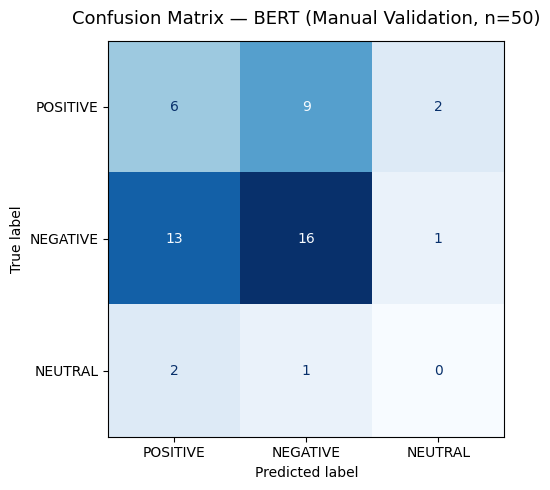

Saved: confusion_matrix_bert.png


In [61]:
y_true = df_eval['manual_label']
y_pred = df_eval['sentiment']
labels = ['POSITIVE', 'NEGATIVE', 'NEUTRAL']

print('=== CLASSIFICATION REPORT — BERT (Manual Validation, n=50) ===')
print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

f1_macro = f1_score(y_true, y_pred, average='macro', labels=labels, zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average='weighted', labels=labels, zero_division=0)
acc = accuracy_score(y_true, y_pred)
print(f'Accuracy       : {acc:.4f}')
print(f'F1-Macro       : {f1_macro:.4f}')
print(f'F1-Weighted    : {f1_weighted:.4f}')

#confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Confusion Matrix — BERT (Manual Validation, n=50)', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('confusion_matrix_bert.png', dpi=150)
plt.show()
print('Saved: confusion_matrix_bert.png')

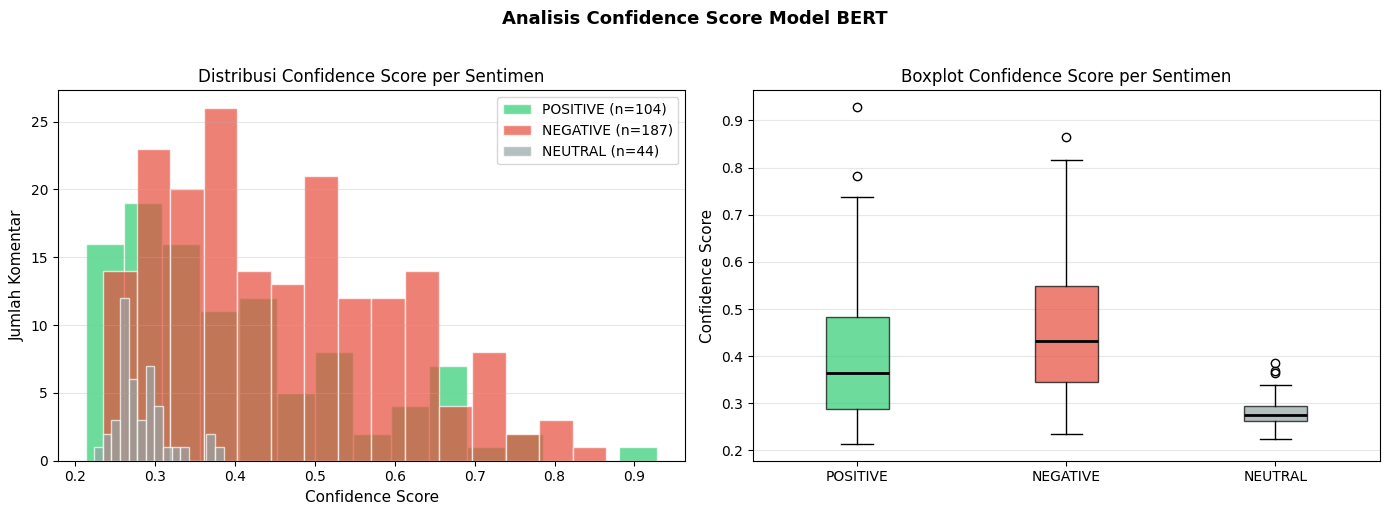

Statistik confidence per sentimen:
           count    mean     std     min     25%     50%     75%     max
sentiment                                                               
NEGATIVE   187.0  0.4576  0.1429  0.2350  0.3462  0.4321  0.5492  0.8647
NEUTRAL     44.0  0.2826  0.0338  0.2236  0.2625  0.2742  0.2943  0.3856
POSITIVE   104.0  0.4035  0.1485  0.2140  0.2890  0.3648  0.4832  0.9280


In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'POSITIVE': '#2ecc71', 'NEGATIVE': '#e74c3c', 'NEUTRAL': '#95a5a6'}
for sentiment, color in colors.items():
    subset = df[df['sentiment'] == sentiment]['confidence']
    axes[0].hist(subset, alpha=0.7, label=f'{sentiment} (n={len(subset)})',
                 color=color, bins=15, edgecolor='white')
axes[0].set_xlabel('Confidence Score', fontsize=11)
axes[0].set_ylabel('Jumlah Komentar', fontsize=11)
axes[0].set_title('Distribusi Confidence Score per Sentimen', fontsize=12)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

conf_data = [df[df['sentiment'] == s]['confidence'].values for s in labels]
bp = axes[1].boxplot(conf_data, labels=labels, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], ['#2ecc71', '#e74c3c', '#95a5a6']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel('Confidence Score', fontsize=11)
axes[1].set_title('Boxplot Confidence Score per Sentimen', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Analisis Confidence Score Model BERT', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Statistik confidence per sentimen:')
print(df.groupby('sentiment')['confidence'].describe().round(4))

In [63]:
HIGH_CONF_THRESHOLD = 0.55
df_eval_model = df_eval.copy()
print(f'Data dengan confidence >= {HIGH_CONF_THRESHOLD}: {len(df_highconf)} komentar')
print('Distribusi:')
print(df_highconf['sentiment'].value_counts())

X = df_eval_model['text_clean']
y = df_eval_model['manual_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nTrain: {len(X_train)} | Test: {len(X_test)}')
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
print(f'\nClass weights: {class_weight_dict}')

Data dengan confidence >= 0.55: 63 komentar
Distribusi:
sentiment
NEGATIVE    46
POSITIVE    17
Name: count, dtype: int64

Train: 40 | Test: 10

Class weights: {'NEGATIVE': np.float64(0.5555555555555556), 'NEUTRAL': np.float64(6.666666666666667), 'POSITIVE': np.float64(0.9523809523809523)}


In [64]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

#model trio
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(
        class_weight=class_weight_dict,
        max_iter=1000,
        random_state=42
    ),
    'Linear SVM': LinearSVC(
        class_weight=class_weight_dict,
        max_iter=2000,
        random_state=42
    )
}

results_models = {}
labels_order = ['POSITIVE', 'NEGATIVE', 'NEUTRAL']

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred_m = model.predict(X_test_tfidf)
    acc_m = accuracy_score(y_test, y_pred_m)
    f1_macro_m = f1_score(y_test, y_pred_m, average='macro',
                          labels=labels_order, zero_division=0)
    f1_weighted_m = f1_score(y_test, y_pred_m, average='weighted',
                             labels=labels_order, zero_division=0)
    results_models[name] = {
        'model': model,
        'y_pred': y_pred_m,
        'accuracy': acc_m,
        'f1_macro': f1_macro_m,
        'f1_weighted': f1_weighted_m
    }
    print(f'\n=== {name} ===')
    print(f'Accuracy    : {acc_m:.4f}')
    print(f'F1-Macro    : {f1_macro_m:.4f}')
    print(f'F1-Weighted : {f1_weighted_m:.4f}')
    print(classification_report(y_test, y_pred_m,
          labels=labels_order, zero_division=0))


=== Naive Bayes ===
Accuracy    : 0.6000
F1-Macro    : 0.2500
F1-Weighted : 0.4500
              precision    recall  f1-score   support

    POSITIVE       0.00      0.00      0.00         3
    NEGATIVE       0.60      1.00      0.75         6
     NEUTRAL       0.00      0.00      0.00         1

    accuracy                           0.60        10
   macro avg       0.20      0.33      0.25        10
weighted avg       0.36      0.60      0.45        10


=== Logistic Regression ===
Accuracy    : 0.5000
F1-Macro    : 0.3481
F1-Weighted : 0.4933
              precision    recall  f1-score   support

    POSITIVE       0.33      0.67      0.44         3
    NEGATIVE       0.75      0.50      0.60         6
     NEUTRAL       0.00      0.00      0.00         1

    accuracy                           0.50        10
   macro avg       0.36      0.39      0.35        10
weighted avg       0.55      0.50      0.49        10


=== Linear SVM ===
Accuracy    : 0.6000
F1-Macro    : 0.7000


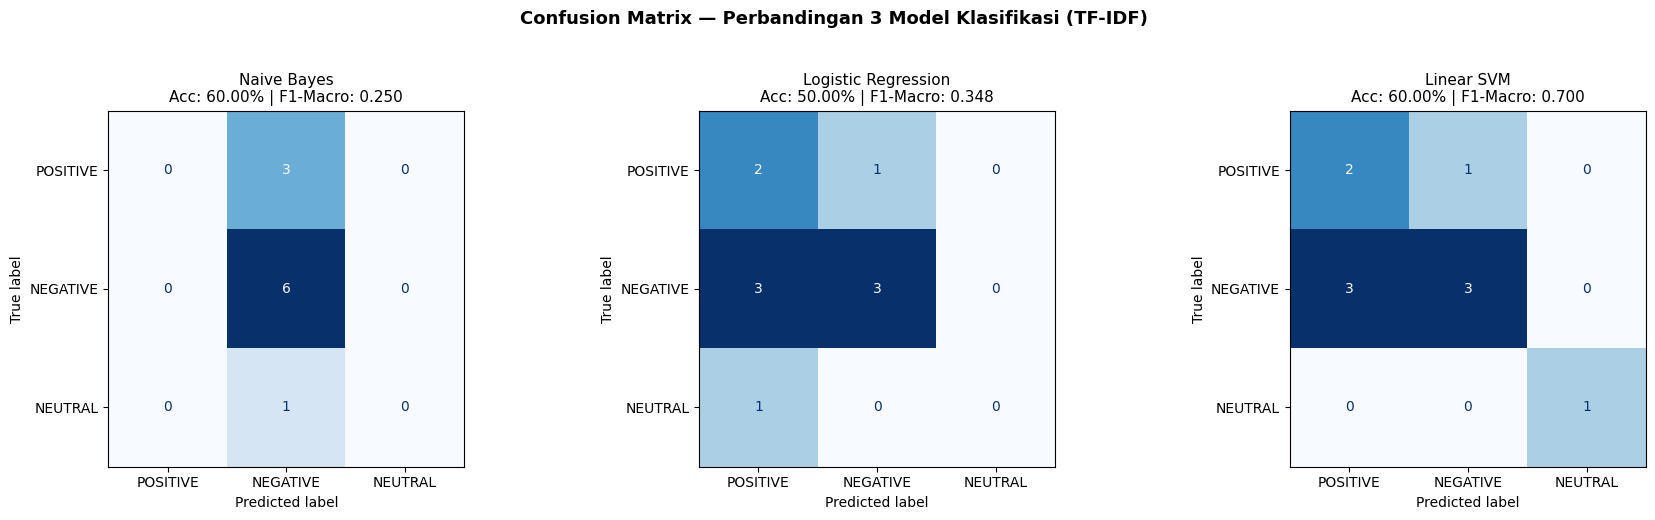

Saved: confusion_matrix_all_models.png


In [65]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, results_models.items()):
    cm = confusion_matrix(y_test, res['y_pred'], labels=labels_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
    disp.plot(cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(
        f'{name}\nAcc: {res["accuracy"]:.2%} | F1-Macro: {res["f1_macro"]:.3f}',
        fontsize=11
    )

plt.suptitle('Confusion Matrix — Perbandingan 3 Model Klasifikasi (TF-IDF)',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('confusion_matrix_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix_all_models.png')

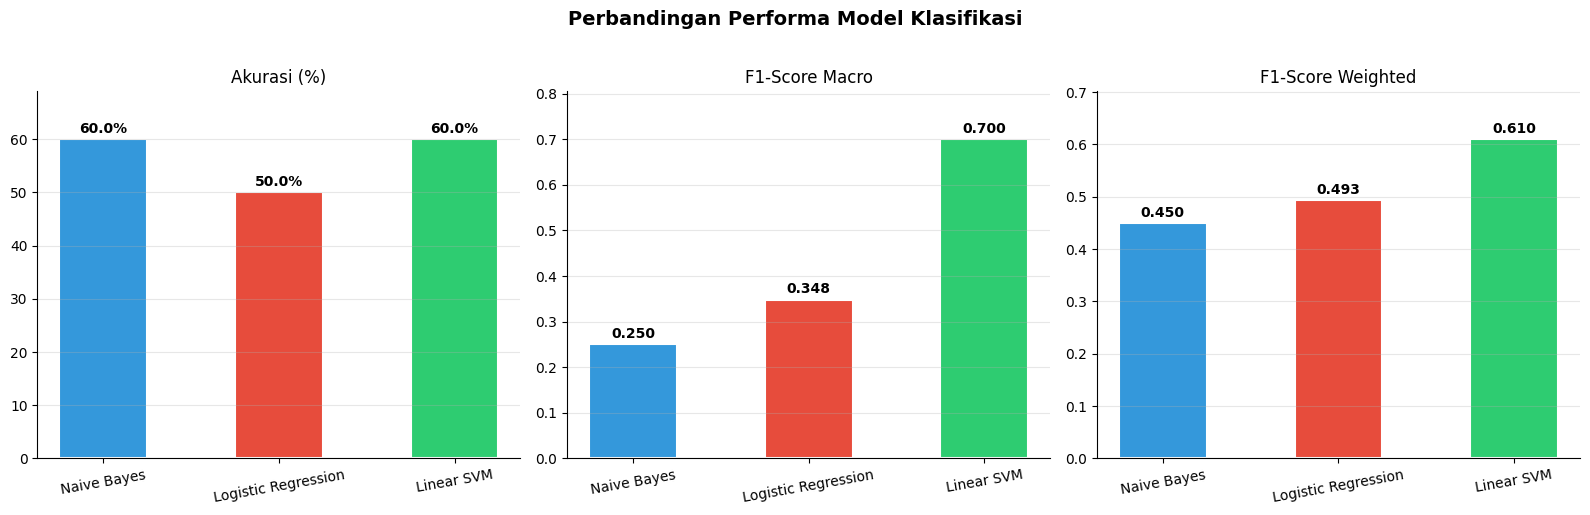

Saved: model_comparison.png


In [66]:
model_names = list(results_models.keys())
accuracies = [results_models[m]['accuracy'] * 100 for m in model_names]
f1_macros = [results_models[m]['f1_macro'] for m in model_names]
f1_weighteds = [results_models[m]['f1_weighted'] for m in model_names]

x = np.arange(len(model_names))
width = 0.25
colors_bar = ['#3498db', '#e74c3c', '#2ecc71']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (values, title, fmt) in zip(axes, [
    (accuracies, 'Akurasi (%)', '{:.1f}%'),
    (f1_macros, 'F1-Score Macro', '{:.3f}'),
    (f1_weighteds, 'F1-Score Weighted', '{:.3f}')
]):
    bars = ax.bar(model_names, values,
                  color=colors_bar, width=0.5, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(values)*0.01,
                fmt.format(val), ha='center', va='bottom',
                fontweight='bold', fontsize=10)
    ax.set_title(title, fontsize=12)
    ax.set_ylim(0, max(values) * 1.15)
    ax.tick_params(axis='x', rotation=10)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Perbandingan Performa Model Klasifikasi', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison.png')

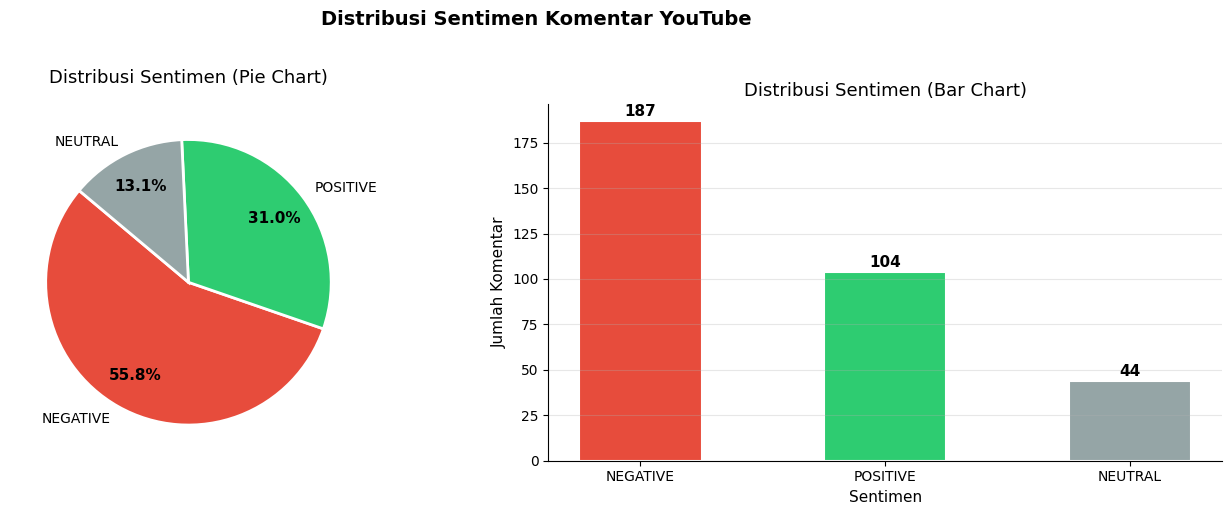

In [67]:
sentiment_counts = df['sentiment'].value_counts()
colors_pie = ['#e74c3c', '#2ecc71', '#95a5a6']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

wedges, texts, autotexts = axes[0].pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    colors=colors_pie,
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    pctdistance=0.75
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(11)
axes[0].set_title('Distribusi Sentimen (Pie Chart)', fontsize=13, pad=15)

bar_colors = [colors_pie[list(sentiment_counts.index).index(s)]
              for s in sentiment_counts.index]
bars = axes[1].bar(sentiment_counts.index, sentiment_counts.values,
                   color=bar_colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, sentiment_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1, str(val),
                 ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[1].set_title('Distribusi Sentimen (Bar Chart)', fontsize=13)
axes[1].set_xlabel('Sentimen', fontsize=11)
axes[1].set_ylabel('Jumlah Komentar', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Distribusi Sentimen Komentar YouTube', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('distribusi_sentimen.png', dpi=150, bbox_inches='tight')
plt.show()

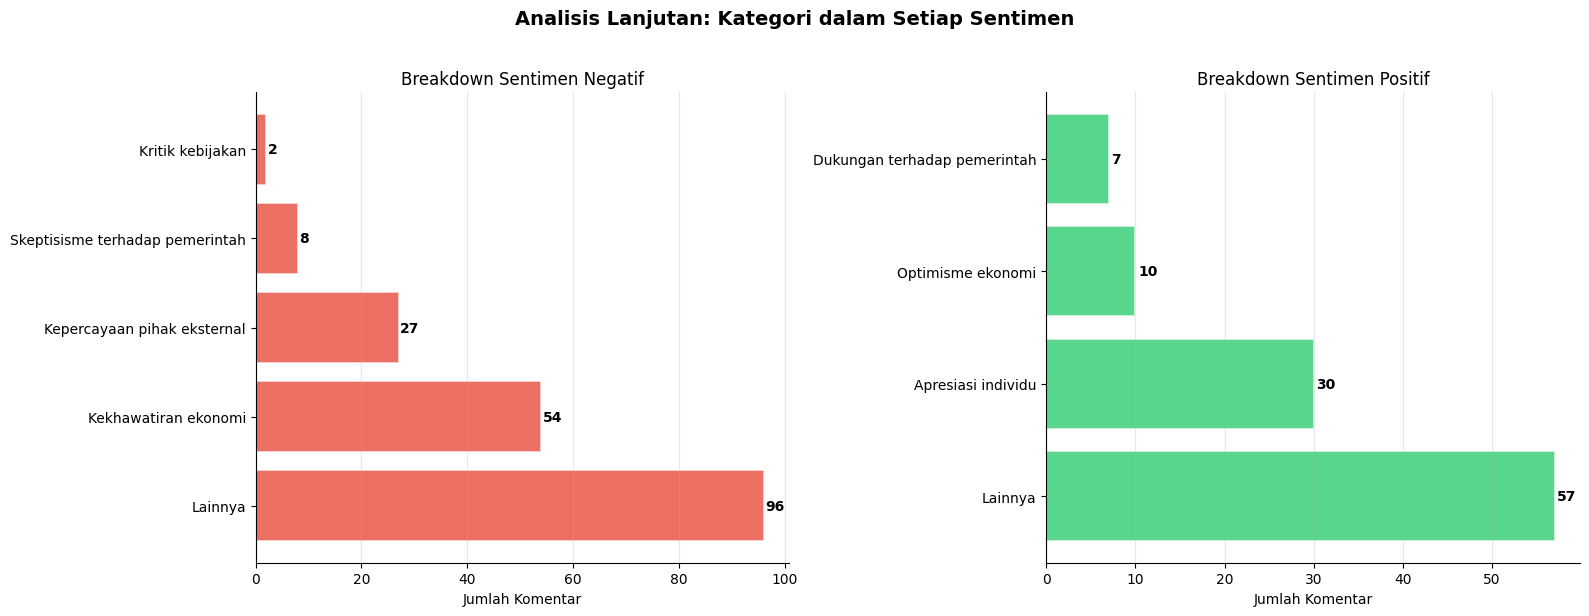

In [68]:
negative_categories = {
    'Skeptisisme terhadap pemerintah': [
        'bohong', 'ngaco', 'tidak percaya', 'salah', 'dusta',
        'pembohong', 'penipu', 'omong kosong', 'omong', 'kibul'
    ],
    'Kekhawatiran ekonomi': [
        'ekonomi', 'utang', 'inflasi', 'harga', 'rupiah',
        'dollar', 'susah', 'miskin', 'rakyat sengsara', 'kenaikan'
    ],
    'Kepercayaan pihak eksternal': [
        'bank dunia', 'world bank', 'imf', 'investor', 'asing',
        'luar negeri', 'barat', 'amerika'
    ],
    'Kritik kebijakan': [
        'kebijakan', 'regulasi', 'aturan', 'salah urus', 'gagal',
        'lambat', 'tidak efektif', 'tidak tepat'
    ]
}

positive_categories = {
    'Dukungan terhadap pemerintah': [
        'dukung', 'setuju', 'mantap', 'bagus', 'hebat',
        'keren', 'lanjutkan', 'bangga', 'salut'
    ],
    'Optimisme ekonomi': [
        'optimis', 'maju', 'berkembang', 'tumbuh', 'membaik',
        'harapan', 'yakin', 'percaya', 'semangat'
    ],
    'Apresiasi individu': [
        'purbaya', 'menteri', 'pemimpin', 'kerja keras', 'dedikasi',
        'profesional', 'kompeten', 'terbaik'
    ]
}

def categorize_negative(text):
    for category, keywords in negative_categories.items():
        if any(kw in text for kw in keywords):
            return category
    return 'Lainnya'

def categorize_positive(text):
    for category, keywords in positive_categories.items():
        if any(kw in text for kw in keywords):
            return category
    return 'Lainnya'

df['analysis'] = None
mask_neg = df['sentiment'] == 'NEGATIVE'
mask_pos = df['sentiment'] == 'POSITIVE'
df.loc[mask_neg, 'analysis'] = df.loc[mask_neg, 'text_clean'].apply(categorize_negative)
df.loc[mask_pos, 'analysis'] = df.loc[mask_pos, 'text_clean'].apply(categorize_positive)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, sentiment, title, color in zip(
    axes,
    ['NEGATIVE', 'POSITIVE'],
    ['Breakdown Sentimen Negatif', 'Breakdown Sentimen Positif'],
    ['#e74c3c', '#2ecc71']
):
    subset = df[df['sentiment'] == sentiment]['analysis'].value_counts()
    bars = ax.barh(subset.index, subset.values, color=color,
                   alpha=0.8, edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, subset.values):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontweight='bold')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Jumlah Komentar', fontsize=10)
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Analisis Lanjutan: Kategori dalam Setiap Sentimen',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('breakdown_sentimen.png', dpi=150, bbox_inches='tight')
plt.show()

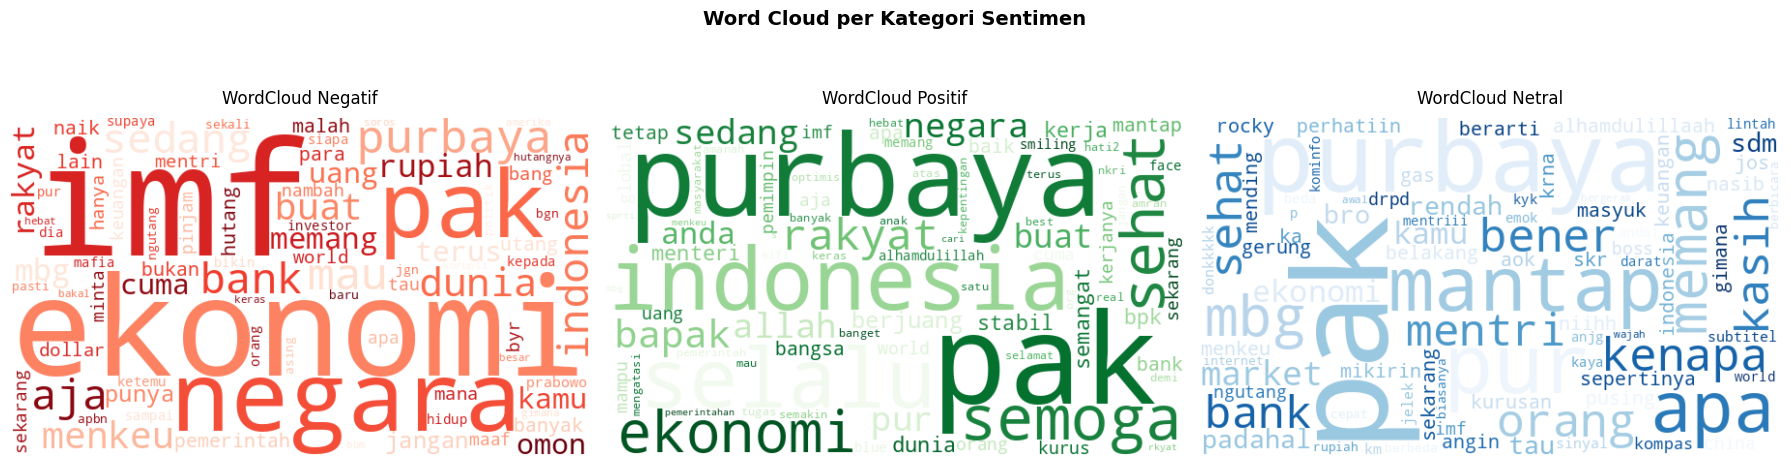

Saved: wordclouds.png


In [69]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

wc_configs = [
    ('NEGATIVE', 'WordCloud Negatif', 'Reds'),
    ('POSITIVE', 'WordCloud Positif', 'Greens'),
    ('NEUTRAL', 'WordCloud Netral', 'Blues'),
]

for ax, (sentiment, title, colormap) in zip(axes, wc_configs):
    text_data = ' '.join(df[df['sentiment'] == sentiment]['text_clean'])
    if len(text_data.strip()) > 0:
        wc = WordCloud(
            width=600, height=350,
            background_color='white',
            colormap=colormap,
            max_words=80,
            collocations=False,
            prefer_horizontal=0.9
        ).generate(text_data)
        ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=12, pad=10)

plt.suptitle('Word Cloud per Kategori Sentimen', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: wordclouds.png')

Kelas yang dilatih: ['NEGATIVE' 'NEUTRAL' 'POSITIVE']


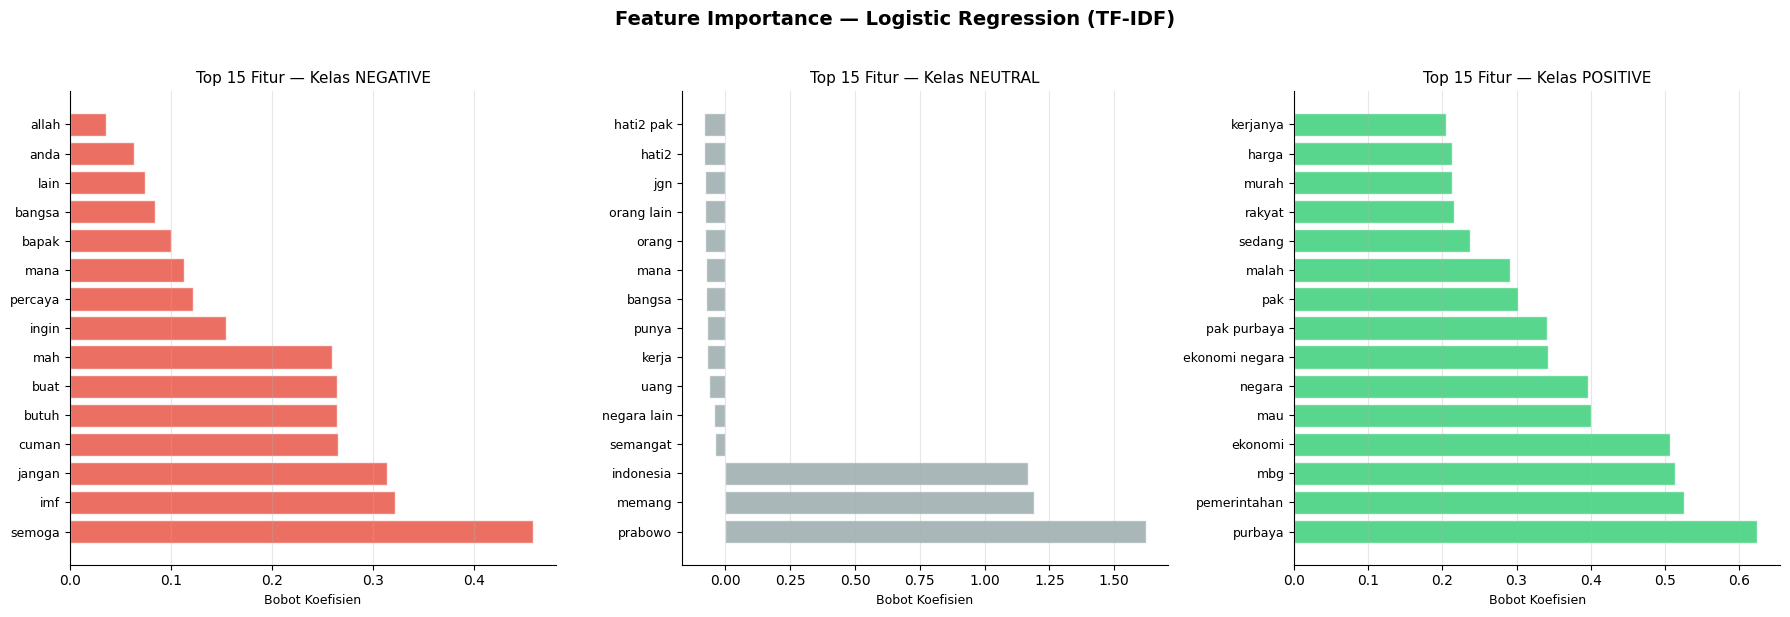

In [70]:
lr_model = results_models['Logistic Regression']['model']
feature_names = np.array(tfidf.get_feature_names_out())

n_classes = len(lr_model.classes_)
print(f'Kelas yang dilatih: {lr_model.classes_}')

fig, axes = plt.subplots(1, n_classes, figsize=(6 * n_classes, 6))
if n_classes == 1:
    axes = [axes]

colors_feat = {'NEGATIVE': '#e74c3c', 'NEUTRAL': '#95a5a6', 'POSITIVE': '#2ecc71'}

for ax, (i, class_name) in zip(axes, enumerate(lr_model.classes_)):
    if n_classes == 2:
        coef = lr_model.coef_[0] if i == 1 else -lr_model.coef_[0]
    else:
        coef = lr_model.coef_[i]

    top_idx = np.argsort(coef)[-15:][::-1]
    top_features = feature_names[top_idx]
    top_coefs = coef[top_idx]

    bars = ax.barh(range(len(top_features)), top_coefs,
                   color=colors_feat.get(class_name, '#3498db'),
                   alpha=0.8, edgecolor='white')
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features, fontsize=9)
    ax.set_title(f'Top 15 Fitur — Kelas {class_name}', fontsize=11)
    ax.set_xlabel('Bobot Koefisien', fontsize=9)
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Feature Importance — Logistic Regression (TF-IDF)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [71]:
#final
print('=' * 60)
print('RINGKASAN ANALISIS SENTIMEN')
print('=' * 60)
print(f'Total komentar dianalisis : {len(df)}')
print()
print('Distribusi Sentimen (BERT):')
for s, count in df['sentiment'].value_counts().items():
    pct = count / len(df) * 100
    print(f'  {s:<12}: {count:>4} ({pct:.1f}%)')

print()
print('Evaluasi Model (TF-IDF, test set):')
print(f'  {"Model":<25} {"Accuracy":>10} {"F1-Macro":>10} {"F1-Weighted":>12}')
print('  ' + '-' * 60)
for name, res in results_models.items():
    print(f'  {name:<25} {res["accuracy"]:>9.4f} {res["f1_macro"]:>10.4f} {res["f1_weighted"]:>12.4f}')

best_model = max(results_models, key=lambda x: results_models[x]['f1_macro'])
print(f'\nModel terbaik berdasarkan F1-Macro: {best_model}')
print('=' * 60)

df.to_csv('hasil_sentimen_lengkap.csv', index=False)
print('\nData tersimpan: hasil_sentimen_lengkap.csv')

RINGKASAN ANALISIS SENTIMEN
Total komentar dianalisis : 335

Distribusi Sentimen (BERT):
  NEGATIVE    :  187 (55.8%)
  POSITIVE    :  104 (31.0%)
  NEUTRAL     :   44 (13.1%)

Evaluasi Model (TF-IDF, test set):
  Model                       Accuracy   F1-Macro  F1-Weighted
  ------------------------------------------------------------
  Naive Bayes                  0.6000     0.2500       0.4500
  Logistic Regression          0.5000     0.3481       0.4933
  Linear SVM                   0.6000     0.7000       0.6100

Model terbaik berdasarkan F1-Macro: Linear SVM

Data tersimpan: hasil_sentimen_lengkap.csv
